<a href="https://colab.research.google.com/github/Arzuyasar/amazon-customer-review/blob/main/Faz%205%20%E2%80%94%20De%C4%9Ferlendirme%20-%20SHAP%20A%C3%A7%C4%B1klanabilirlik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q shap lightgbm scikit-learn pyarrow matplotlib plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
from IPython.display import display

from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/'
print("Hazır")

Mounted at /content/drive
Hazır


In [3]:
with open(DRIVE_PATH + 'final_model.pkl', 'rb') as f:
    final_model = pickle.load(f)
with open(DRIVE_PATH + 'tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open(DRIVE_PATH + 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

df = pd.read_parquet(DRIVE_PATH + 'faz3_nlp_sonuc.parquet')

NUM_COLS = [
    'star_rating', 'body_len', 'word_count',
    'exclamation_cnt', 'question_cnt', 'upper_ratio',
    'has_caps_word', 'is_verified', 'is_vine',
]

df_model = df.dropna(subset=['is_problem', 'review_body']).copy()
df_model[NUM_COLS] = df_model[NUM_COLS].fillna(0)

X_text = tfidf.transform(df_model['review_body'].fillna(''))
X_num  = csr_matrix(scaler.transform(df_model[NUM_COLS].astype(float)))
X      = hstack([X_text, X_num])
y      = df_model['is_problem'].values

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Model ve veri yüklendi")
print(f"Test seti: {X_test.shape[0]:,} satır")

Model ve veri yüklendi
Test seti: 40,000 satır


In [4]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("── Sınıf Bazında Değerlendirme ──────────────────────────")
print(classification_report(y_test, y_pred,
      target_names=['Olumlu (0)', 'Problemli (1)'],
      digits=4))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_prob):.4f}")

── Sınıf Bazında Değerlendirme ──────────────────────────
               precision    recall  f1-score   support

   Olumlu (0)     1.0000    1.0000    1.0000     28277
Problemli (1)     1.0000    1.0000    1.0000     11723

     accuracy                         1.0000     40000
    macro avg     1.0000    1.0000    1.0000     40000
 weighted avg     1.0000    1.0000    1.0000     40000

ROC-AUC Skoru: 1.0000


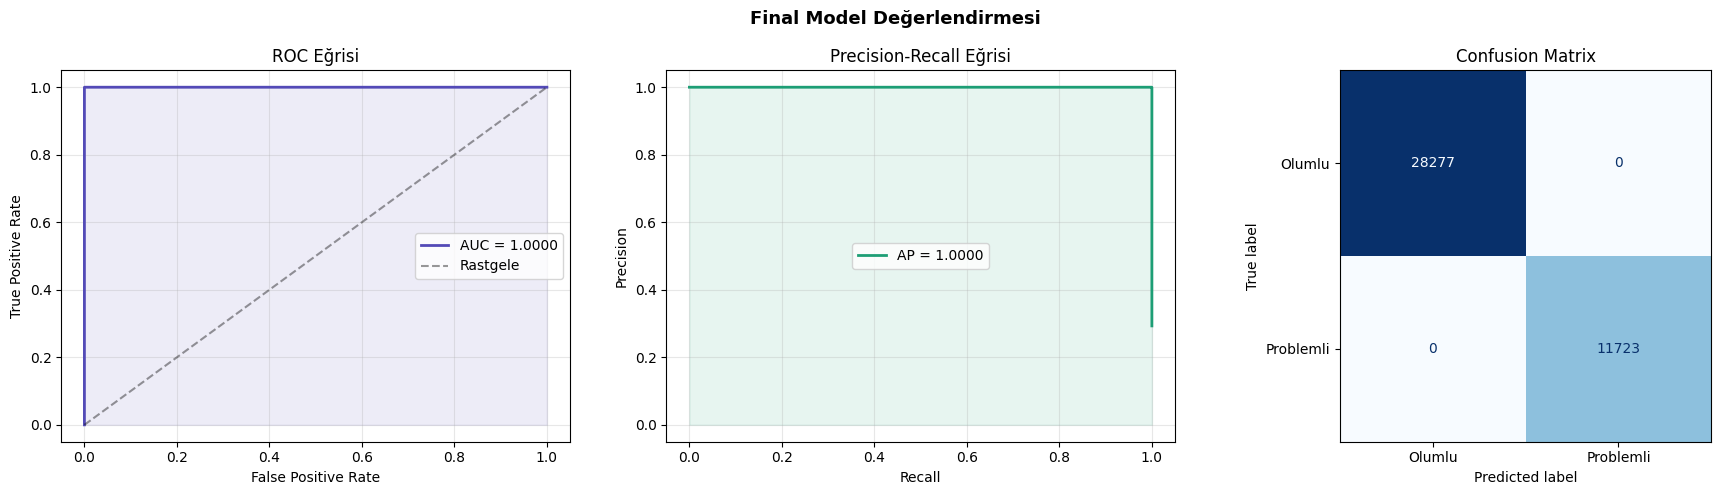

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Final Model Değerlendirmesi', fontsize=13, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc         = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#534AB7', linewidth=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Rastgele')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#534AB7')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Eğrisi')
axes[0].legend()
axes[0].grid(alpha=0.3)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1].plot(recall, precision, color='#1D9E75', linewidth=2, label=f'AP = {ap:.4f}')
axes[1].fill_between(recall, precision, alpha=0.1, color='#1D9E75')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Eğrisi')
axes[1].legend()
axes[1].grid(alpha=0.3)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Olumlu', 'Problemli'],
    cmap='Blues', ax=axes[2], colorbar=False
)
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('final_degerlendirme.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print("SHAP değerleri hesaplanıyor (birkaç dakika sürebilir)...")

N_ORNEK = 1000
X_dense  = X_test[:N_ORNEK].toarray()

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_dense)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

feature_names = (
    tfidf.get_feature_names_out().tolist() +
    NUM_COLS
)

print(" SHAP değerleri hazır")
print(f"   Şekil: {sv.shape}")

SHAP değerleri hesaplanıyor (birkaç dakika sürebilir)...
 SHAP değerleri hazır
   Şekil: (1000, 5009)


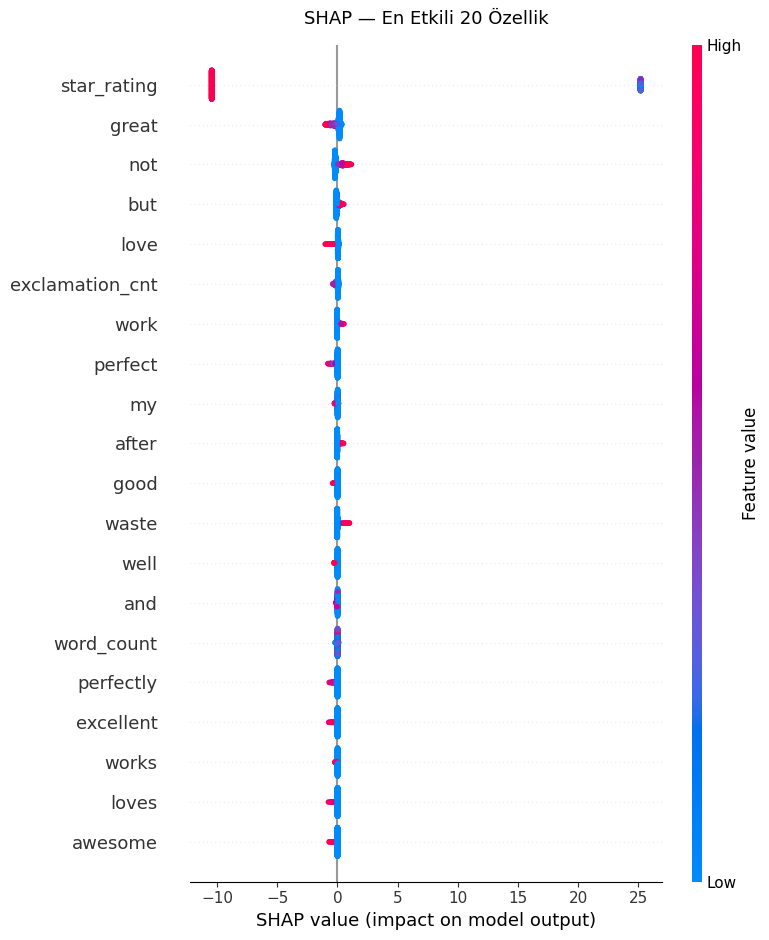

 shap_summary.png kaydedildi


In [7]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_dense,
    feature_names=feature_names,
    max_display=20,
    show=False,
    plot_type='dot'
)
plt.title('SHAP — En Etkili 20 Özellik', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(" shap_summary.png kaydedildi")

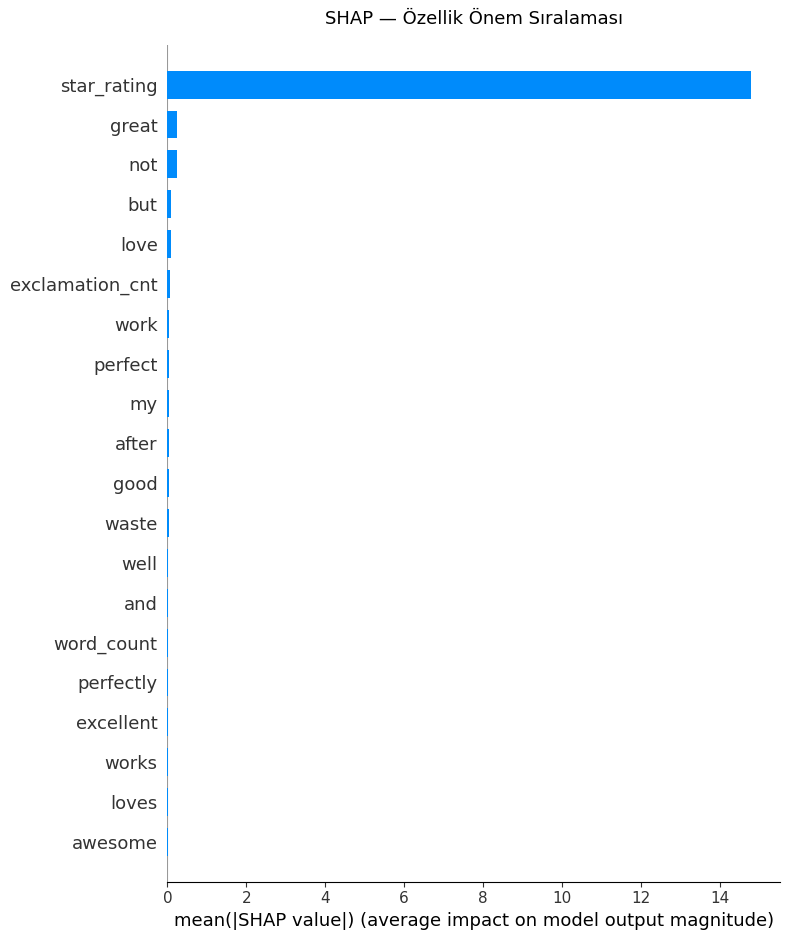

In [8]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, X_dense,
    feature_names=feature_names,
    max_display=20,
    show=False,
    plot_type='bar'
)
plt.title('SHAP — Özellik Önem Sıralaması', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

── Seçilen Yorum ─────────────────────────────────────────
Metin   : Used this for Elite Dangerous on my mac, an amazing joystick. I especially love that you can twist the stick for different movement bindings as well as move it in the normal way....
Gerçek  : Problemli 
Tahmin  : Problemli 
Olasılık: %100.0


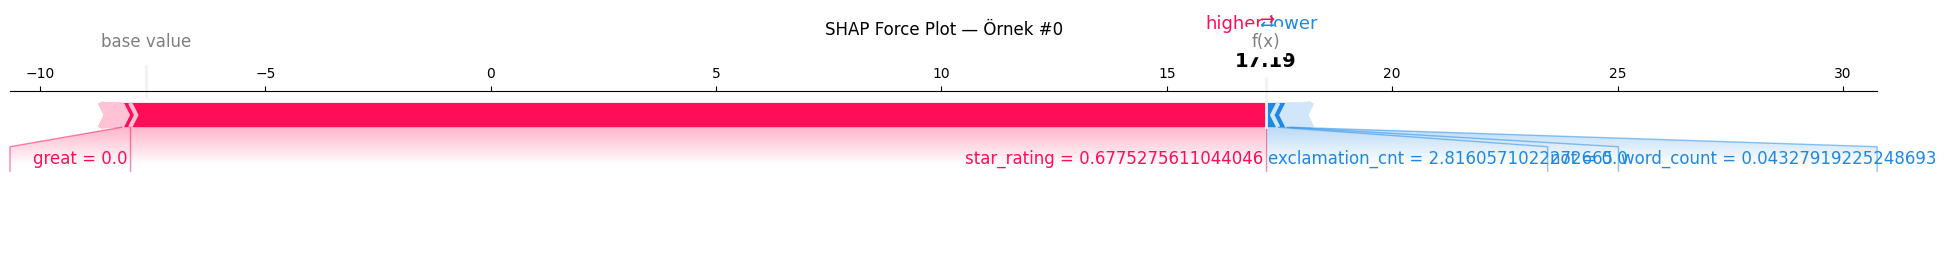

In [10]:
problemli_idxler = np.where(y_test == 1)[0]
ornek_idx        = problemli_idxler[0]

ornek_yorum = df_model['review_body'].iloc[ornek_idx]
gercek      = y_test[ornek_idx]
tahmin      = y_pred[ornek_idx]
olasilik    = y_prob[ornek_idx]

print("── Seçilen Yorum ─────────────────────────────────────────")
print(f"Metin   : {ornek_yorum[:200]}...")
print(f"Gerçek  : {'Problemli ' if gercek==1 else 'Olumlu '}")
print(f"Tahmin  : {'Problemli ' if tahmin==1 else 'Olumlu '}")
print(f"Olasılık: %{olasilik*100:.1f}")

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list)
    else explainer.expected_value,
    sv[ornek_idx],
    X_dense[ornek_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Örnek #{ornek_idx}', pad=40)
plt.tight_layout()
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

── Departman Bazında Özet ───────────────────────────────


,yorum_sayisi,ort_yildiz,ort_guven
departman_tr,,,
Arşiv (Olumlu),141384,4.78,1.00
Teknik Destek,28992,1.79,0.33
Yazılım Ekibi,11330,1.78,0.59
Ürün Yönetimi,10695,1.97,0.61
Lojistik,5483,1.63,0.58
Müşteri Hizmetleri,2116,1.62,0.62


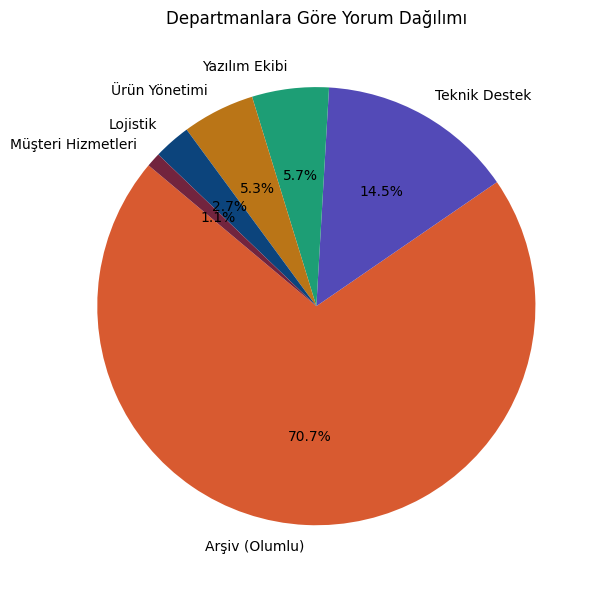

In [11]:
if 'departman_tr' in df_model.columns:
    dept_analiz = df_model.groupby('departman_tr').agg(
        yorum_sayisi=('review_body', 'count'),
        ort_yildiz  =('star_rating', 'mean'),
        ort_guven   =('guven_skoru', 'mean'),
    ).round(2).sort_values('yorum_sayisi', ascending=False)

    print("── Departman Bazında Özet ───────────────────────────────")
    display(dept_analiz)

    fig, ax = plt.subplots(figsize=(8, 6))
    renkler = ['#D85A30','#534AB7','#1D9E75','#BA7517','#0C447C','#72243E']
    ax.pie(dept_analiz['yorum_sayisi'],
           labels=dept_analiz.index,
           autopct='%1.1f%%',
           colors=renkler[:len(dept_analiz)],
           startangle=140)
    ax.set_title('Departmanlara Göre Yorum Dağılımı')
    plt.tight_layout()
    plt.savefig('departman_dagilim.png', dpi=150, bbox_inches='tight')
    plt.show()

In [12]:
import shutil

grafik_dosyalari = [
    'final_degerlendirme.png',
    'shap_summary.png',
    'shap_bar.png',
    'shap_force.png',
    'departman_dagilim.png',
]

print("Grafikler Drive'a kopyalanıyor...")
for dosya in grafik_dosyalari:
    if os.path.exists(dosya):
        shutil.copy(dosya, DRIVE_PATH + dosya)
        print(f"   {dosya}")
    else:
        print(f"   {dosya} bulunamadı")

print(f"\n Tüm fazlar tamamlandı!")
print(f"   Sonraki adım → Streamlit arayüzü (app.py)")

Grafikler Drive'a kopyalanıyor...
   final_degerlendirme.png
   shap_summary.png
   shap_bar.png
   shap_force.png
   departman_dagilim.png

 Tüm fazlar tamamlandı!
   Sonraki adım → Streamlit arayüzü (app.py)
